# 🧊 Sea Ice SAR Segmentation — Google Colab Training

**Model:** 8-Module Pipeline (CLIP ViT-L/14 + DepthAnything V2 + SAM + Cross-Attention CoT)

**Task:** 6-class sea ice segmentation from SAR imagery

**Classes:** Young Ice · First Year Ice · Floating Ice · Glaciers · Icebergs · Old Ice

---
**Before you start:**
1. `Runtime → Change runtime type → GPU` (T4 is free, A100/V100 via Colab Pro)
2. Run cells **in order** from top to bottom
3. Checkpoints auto-save to Google Drive every 1 000 steps

> ⏱ Estimated training time: ~3–4 h (T4, 50 epochs, no SAM) | ~6–8 h (A100, with SAM)

## 1. 🖥️ Check GPU

In [1]:
import subprocess, sys, os

# GPU info
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode != 0:
    raise RuntimeError('❌ No GPU detected! Go to Runtime → Change runtime type → GPU')
print(result.stdout)

import torch
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.version.cuda}')
print(f'Device   : {torch.cuda.get_device_name(0)}')
print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

GPU_NAME = torch.cuda.get_device_name(0)
VRAM_GB  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'\n✅ GPU ready: {GPU_NAME} ({VRAM_GB:.0f} GB)')

Wed May 27 17:10:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. 📂 Mount Google Drive (for persistent checkpoints)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR = '/content/drive/MyDrive/sea_ice_seg'
os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(f'{DRIVE_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{DRIVE_DIR}/outputs', exist_ok=True)
print(f'✅ Drive mounted. Project folder: {DRIVE_DIR}')

Mounted at /content/drive
✅ Drive mounted. Project folder: /content/drive/MyDrive/sea_ice_seg


## 3. 📥 Clone Repository

In [3]:
import os

REPO_URL  = 'https://github.com/prakhar443/sea_ice_seg.git'
REPO_DIR  = '/content/sea_ice_seg'

if os.path.exists(REPO_DIR):
    print('Repo already cloned. Pulling latest...')
    !git -C {REPO_DIR} pull origin main
else:
    print('Cloning repository...')
    !git clone {REPO_URL} {REPO_DIR}

os.chdir(REPO_DIR)
print(f'\n✅ Working directory: {os.getcwd()}')
!ls -la

Cloning repository...
Cloning into '/content/sea_ice_seg'...
remote: Enumerating objects: 1266, done.
remote: Counting objects: 100% (1266/1266), done.
remote: Compressing objects: 100% (1247/1247), done.
remote: Total 1266 (delta 19), reused 1266 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (1266/1266), 13.41 MiB | 36.22 MiB/s, done.
Resolving deltas: 100% (19/19), done.

✅ Working directory: /content/sea_ice_seg
total 100
drwxr-xr-x 8 root root  4096 May 27 17:11 .
drwxr-xr-x 1 root root  4096 May 27 17:11 ..
-rw-r--r-- 1 root root  8125 May 27 17:11 config.py
drwxr-xr-x 2 root root  4096 May 27 17:11 data
drwxr-xr-x 8 root root  4096 May 27 17:11 dataset
drwxr-xr-x 2 root root  4096 May 27 17:11 DOCUMENTATION
-rw-r--r-- 1 root root 14818 May 27 17:11 evaluate.py
drwxr-xr-x 8 root root  4096 May 27 17:11 .git
-rw-r--r-- 1 root root 14011 May 27 17:11 inference.py
drwxr-xr-x 2 root root  4096 May 27 17:11 models
-rw-r--r-- 1 root root  8431 May 27 17:11 quickstart.py
-rw

## 4. 📦 Install Dependencies

> Takes ~3–5 minutes on first run. Subsequent runs are faster.

In [4]:
print('Installing core dependencies...')
!pip install -q \
    transformers>=4.40.0 \
    peft>=0.10.0 \
    accelerate>=0.27.0 \
    einops>=0.7.0 \
    timm>=0.9.0 \
    albumentations>=1.4.0 \
    openpyxl \
    pandas \
    scipy \
    scikit-learn \
    tqdm \
    wandb

print('\nInstalling Segment Anything Model (SAM)...')
!pip install -q git+https://github.com/facebookresearch/segment-anything.git

print('\nVerifying key packages...')
import importlib
for pkg in ['transformers', 'peft', 'albumentations', 'segment_anything', 'einops', 'timm']:
    try:
        m = importlib.import_module(pkg)
        ver = getattr(m, '__version__', 'ok')
        print(f'  ✅ {pkg} {ver}')
    except ImportError:
        print(f'  ❌ {pkg} NOT FOUND')

print('\n✅ All dependencies installed!')

Installing core dependencies...

Installing Segment Anything Model (SAM)...
  Preparing metadata (setup.py) ... done

Verifying key packages...
  ✅ transformers 5.0.0
  ✅ peft 0.19.1
  ✅ albumentations 2.0.8
  ✅ segment_anything ok
  ✅ einops 0.8.2
  ✅ timm 1.0.27

✅ All dependencies installed!


## 5. ⚙️ Auto-configure Hyperparameters for Your GPU

Automatically picks the right batch size, memory-efficient settings, and whether to use SAM.

In [5]:
import torch

VRAM_GB = torch.cuda.get_device_properties(0).total_memory / 1e9
GPU_NAME = torch.cuda.get_device_name(0)

# ─── Auto-select settings based on available VRAM ────────────────────────────
if VRAM_GB >= 38:   # A100 (40 GB)
    BATCH_SIZE     = 4
    USE_SAM        = True
    GRAD_ACCUM     = 4      # effective batch = 16
    NUM_WORKERS    = 4
    IMAGE_SIZE     = (512, 512)
    LLM_BACKEND    = 'cross_attn_only'
elif VRAM_GB >= 14:  # T4 / V100 (15–16 GB)
    BATCH_SIZE     = 2
    USE_SAM        = False  # SAM ViT-H needs ~8 GB extra
    GRAD_ACCUM     = 8      # effective batch = 16
    NUM_WORKERS    = 2
    IMAGE_SIZE     = (512, 512)
    LLM_BACKEND    = 'cross_attn_only'
else:               # < 14 GB (smaller GPUs)
    BATCH_SIZE     = 1
    USE_SAM        = False
    GRAD_ACCUM     = 16     # effective batch = 16
    NUM_WORKERS    = 2
    IMAGE_SIZE     = (384, 384)
    LLM_BACKEND    = 'cross_attn_only'

# ─── Training settings ────────────────────────────────────────────────────────
EPOCHS        = 50
LEARNING_RATE = 2e-4
USE_FP16      = True
USE_WANDB     = False     # Set True and add your API key for W&B logging
WANDB_PROJECT = 'sea-ice-seg'

DATA_ROOT     = '/content/sea_ice_seg/dataset'
OUTPUT_DIR    = '/content/sea_ice_seg/outputs'
DRIVE_OUTPUT  = '/content/drive/MyDrive/sea_ice_seg/outputs'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('═' * 55)
print(f'  GPU          : {GPU_NAME} ({VRAM_GB:.0f} GB)')
print(f'  Batch size   : {BATCH_SIZE}  (effective = {BATCH_SIZE * GRAD_ACCUM})')
print(f'  Grad accum   : {GRAD_ACCUM} steps')
print(f'  Use SAM      : {USE_SAM}')
print(f'  FP16         : {USE_FP16}')
print(f'  Epochs       : {EPOCHS}')
print(f'  LLM backend  : {LLM_BACKEND}')
print(f'  Image size   : {IMAGE_SIZE}')
print(f'  Output dir   : {OUTPUT_DIR}')
print('═' * 55)

═══════════════════════════════════════════════════════
  GPU          : Tesla T4 (16 GB)
  Batch size   : 2  (effective = 16)
  Grad accum   : 8 steps
  Use SAM      : False
  FP16         : True
  Epochs       : 50
  LLM backend  : cross_attn_only
  Image size   : (512, 512)
  Output dir   : /content/sea_ice_seg/outputs
═══════════════════════════════════════════════════════


## 6. 🔍 Verify Dataset Structure

In [6]:
import os
from pathlib import Path

data_root = Path(DATA_ROOT)
ice_classes = ['Young Ice', 'First Year Ice', 'Floating Ice',
               'Glaciers', 'Icebergs', 'Old Ice']

print('Dataset structure:')
print('=' * 60)
total_images = 0
total_masks  = 0
for cls in ice_classes:
    cls_dir   = data_root / cls
    img_dir   = cls_dir / 'images'
    mask_dir  = cls_dir / 'masks'
    desc_dir  = cls_dir / 'descriptions'

    n_imgs  = len(list(img_dir.glob('*')))  if img_dir.exists()  else 0
    n_masks = len(list(mask_dir.glob('*'))) if mask_dir.exists() else 0
    n_desc  = len(list(desc_dir.glob('*.xlsx'))) if desc_dir.exists() else 0

    status = '✅' if (n_imgs > 0 and n_masks > 0) else '❌'
    print(f'{status} {cls:<20} images={n_imgs:>4}  masks={n_masks:>4}  xlsx={n_desc}')
    total_images += n_imgs
    total_masks  += n_masks

print('=' * 60)
print(f'Total: {total_images} images  |  {total_masks} masks')
print()
if total_images == 0:
    print('❌ No images found! Make sure the dataset was included in the repo.')
else:
    print(f'✅ Dataset ready — {total_images} samples across {len(ice_classes)} classes')

Dataset structure:
✅ Young Ice            images= 100  masks= 100  xlsx=1
✅ First Year Ice       images= 100  masks= 100  xlsx=1
✅ Floating Ice         images= 100  masks= 100  xlsx=0
✅ Glaciers             images= 100  masks= 100  xlsx=1
✅ Icebergs             images= 100  masks= 100  xlsx=0
✅ Old Ice              images= 100  masks= 100  xlsx=0
Total: 600 images  |  600 masks

✅ Dataset ready — 600 samples across 6 classes


## 7. 🖼️ Visualise Sample Images

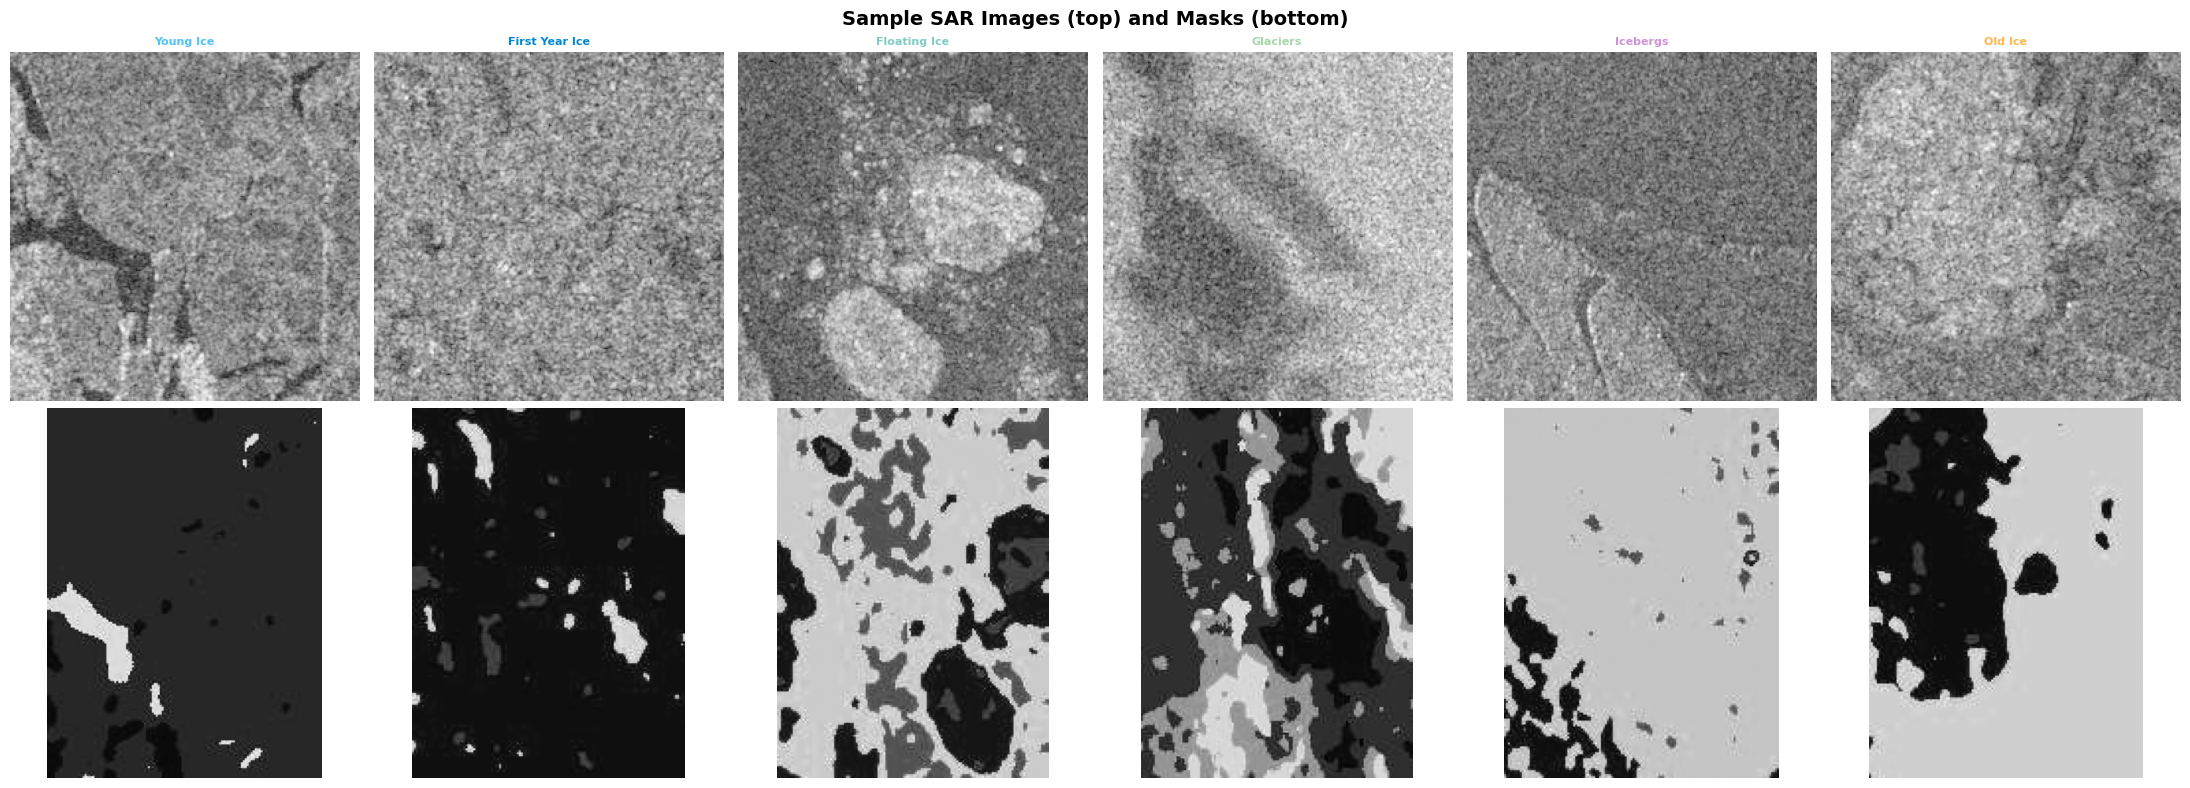

✅ Sample visualisation saved to /content/sample_images.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import numpy as np
from pathlib import Path

data_root   = Path(DATA_ROOT)
ice_classes = ['Young Ice', 'First Year Ice', 'Floating Ice',
               'Glaciers', 'Icebergs', 'Old Ice']
colors = ['#4FC3F7','#0288D1','#80CBC4','#A5D6A7','#CE93D8','#FFB74D']

fig, axes = plt.subplots(2, 6, figsize=(22, 8))
fig.suptitle('Sample SAR Images (top) and Masks (bottom)', fontsize=14, fontweight='bold')

for col, cls in enumerate(ice_classes):
    img_dir  = data_root / cls / 'images'
    mask_dir = data_root / cls / 'masks'
    imgs = sorted(img_dir.glob('*.jpg'))
    if not imgs:
        continue

    # Pick first image
    img_path  = imgs[0]
    stem      = img_path.stem.rstrip('_')
    mask_path = mask_dir / (stem + '_scat.jpg')

    img  = Image.open(img_path).convert('RGB')
    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].set_title(cls, fontsize=8, color=colors[col], fontweight='bold')
    axes[0, col].axis('off')

    if mask_path.exists():
        mask = Image.open(mask_path).convert('L')
        axes[1, col].imshow(mask, cmap='gray')
    else:
        axes[1, col].text(0.5, 0.5, 'No mask', ha='center', va='center',
                          transform=axes[1, col].transAxes)
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Sample visualisation saved to /content/sample_images.png')

## 8. 🏋️ (Optional) Download SAM Checkpoint

SAM ViT-H improves segmentation accuracy but requires **~8 GB extra VRAM**.  
Skip this cell if your GPU has ≤ 16 GB or if `USE_SAM = False`.

In [8]:
import os

SAM_CHECKPOINT = '/content/sea_ice_seg/checkpoints/sam_vit_h_4b8939.pth'
SAM_URL        = 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth'

os.makedirs('/content/sea_ice_seg/checkpoints', exist_ok=True)

# Check Drive cache first (saves re-downloading)
DRIVE_SAM = '/content/drive/MyDrive/sea_ice_seg/checkpoints/sam_vit_h_4b8939.pth'

if not USE_SAM:
    print('USE_SAM = False → skipping SAM download (lightweight decoder will be used)')
elif os.path.exists(SAM_CHECKPOINT):
    print(f'✅ SAM checkpoint already exists: {SAM_CHECKPOINT}')
elif os.path.exists(DRIVE_SAM):
    print('Copying SAM checkpoint from Drive cache...')
    !cp {DRIVE_SAM} {SAM_CHECKPOINT}
    print('✅ Copied from Drive')
else:
    print('Downloading SAM ViT-H checkpoint (~2.5 GB) ...')
    print('This takes ~5 minutes on Colab.')
    !wget -q --show-progress -O {SAM_CHECKPOINT} {SAM_URL}

    # Cache to Drive for future sessions
    os.makedirs('/content/drive/MyDrive/sea_ice_seg/checkpoints', exist_ok=True)
    !cp {SAM_CHECKPOINT} {DRIVE_SAM}
    print('✅ SAM checkpoint downloaded and cached to Drive')

USE_SAM = False → skipping SAM download (lightweight decoder will be used)


## 9. 🔧 Patch Config for Colab

Overrides `config.py` settings with the auto-selected Colab values.

In [9]:
import sys
sys.path.insert(0, '/content/sea_ice_seg')

from config import cfg

# ── Data config ───────────────────────────────────────────────────────────────
cfg.data.data_root  = DATA_ROOT
cfg.data.image_size = IMAGE_SIZE

# ── Model config ──────────────────────────────────────────────────────────────
cfg.model.llm_backend     = LLM_BACKEND
cfg.model.sam_checkpoint  = SAM_CHECKPOINT

# ── Train config ──────────────────────────────────────────────────────────────
cfg.train.batch_size       = BATCH_SIZE
cfg.train.grad_accum_steps = GRAD_ACCUM
cfg.train.epochs           = EPOCHS
cfg.train.lr               = LEARNING_RATE
cfg.train.fp16             = USE_FP16
cfg.train.num_workers      = NUM_WORKERS
cfg.train.output_dir       = OUTPUT_DIR
cfg.train.use_wandb        = USE_WANDB
cfg.train.wandb_project    = WANDB_PROJECT
cfg.train.eval_every       = 200   # validate more frequently on small dataset
cfg.train.save_every       = 500

print('Config patched for Colab:')
print(f'  data_root        = {cfg.data.data_root}')
print(f'  image_size       = {cfg.data.image_size}')
print(f'  batch_size       = {cfg.train.batch_size}')
print(f'  grad_accum       = {cfg.train.grad_accum_steps}')
print(f'  epochs           = {cfg.train.epochs}')
print(f'  lr               = {cfg.train.lr}')
print(f'  fp16             = {cfg.train.fp16}')
print(f'  num_workers      = {cfg.train.num_workers}')
print(f'  llm_backend      = {cfg.model.llm_backend}')
print(f'  use_sam          = {USE_SAM}')
print(f'  use_wandb        = {cfg.train.use_wandb}')
print('\n✅ Config ready')

Config patched for Colab:
  data_root        = /content/sea_ice_seg/dataset
  image_size       = (512, 512)
  batch_size       = 2
  grad_accum       = 8
  epochs           = 50
  lr               = 0.0002
  fp16             = True
  num_workers      = 2
  llm_backend      = cross_attn_only
  use_sam          = False
  use_wandb        = False

✅ Config ready


## 10. 📊 Build Dataloaders & Inspect

In [11]:
import sys
sys.path.insert(0, '/content/sea_ice_seg')

from data.dataset import build_dataloaders

train_loader, val_loader, test_loader = build_dataloaders(cfg.data, cfg.train)

# Peek at one batch
batch = next(iter(train_loader))
print('\nBatch shapes:')
print(f'  image  : {batch["image"].shape}   dtype={batch["image"].dtype}')
print(f'  mask   : {batch["mask"].shape}    dtype={batch["mask"].dtype}')
print(f'  label  : {batch["label"]}')
print(f'  short  : {batch["short_desc"][0][:60]}...')
print(f'  long   : {batch["long_desc"][0][:80]}...')
print(f'\n✅ Dataloaders ready')

ValueError: 1 validation error for InitSchema
size
  Field required [type=missing, input_value={'scale': (0.7, 1.0), 'p'...: None, 'strict': False}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing

## 11. 🏗️ Build Model

In [ ]:
import torch, sys
sys.path.insert(0, '/content/sea_ice_seg')

from models.pipeline import SeaIceSegmentationPipeline

device = cfg.train.device
print(f'Building model on {device}...')
print('  CLIP ViT-L/14 + LoRA  — downloading from HuggingFace if needed...')
print('  DepthAnything V2       — downloading from HuggingFace if needed...')
print('  (first run may take a few minutes)\n')

model = SeaIceSegmentationPipeline(cfg.model, use_sam=USE_SAM).to(device)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params   = total_params - trainable_params

print(f'\nModel summary:')
print(f'  Total parameters    : {total_params:>12,}')
print(f'  Trainable (LoRA+head): {trainable_params:>12,}')
print(f'  Frozen (CLIP/Depth) : {frozen_params:>12,}')

vram_used = torch.cuda.memory_allocated(0) / 1e9
print(f'\n  VRAM used after model load: {vram_used:.2f} GB / {VRAM_GB:.0f} GB')
print(f'\n✅ Model ready on {device}')

## 12. 🚀 Train the Model

> Checkpoints are saved to `OUTPUT_DIR` every `save_every` steps.  
> Best model is always saved as `best_model.pth` when val F1 improves.

In [ ]:
import os, sys, math, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
from tqdm.notebook import tqdm
sys.path.insert(0, '/content/sea_ice_seg')

from utils.losses  import SeaIceLoss
from utils.metrics import MetricAccumulator
from train import set_seed, get_lr_scheduler, save_checkpoint, validate, cleanup_old_checkpoints

set_seed(cfg.train.seed)

output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

# ── Optimizer ─────────────────────────────────────────────────────────────────
param_groups = model.get_param_groups(cfg.model, cfg.train)
optimizer    = torch.optim.AdamW(
    param_groups,
    lr=cfg.train.lr,
    weight_decay=cfg.train.weight_decay,
    betas=cfg.train.betas,
)

# ── Scheduler ─────────────────────────────────────────────────────────────────
steps_per_epoch  = len(train_loader) // cfg.train.grad_accum_steps
total_steps      = steps_per_epoch * cfg.train.epochs
scheduler        = get_lr_scheduler(optimizer, cfg.train, total_steps)

# ── Mixed precision ───────────────────────────────────────────────────────────
scaler = GradScaler() if cfg.train.fp16 else None

# ── Loss ──────────────────────────────────────────────────────────────────────
criterion = SeaIceLoss(cfg.train).to(device)

# ── (Optional) Resume from checkpoint ────────────────────────────────────────
RESUME_CHECKPOINT = None   # e.g. '/content/drive/MyDrive/sea_ice_seg/outputs/best_model.pth'

start_epoch  = 0
start_step   = 0
best_metric  = 0.0

if RESUME_CHECKPOINT and os.path.exists(RESUME_CHECKPOINT):
    from train import load_checkpoint
    ckpt        = load_checkpoint(model, optimizer, scheduler, scaler,
                                  Path(RESUME_CHECKPOINT), device)
    start_epoch = ckpt['epoch']
    start_step  = ckpt['step']
    best_metric = ckpt['best_metric']

print(f'Training for {cfg.train.epochs} epochs, {total_steps} total optimizer steps')
print(f'Resuming: epoch={start_epoch}, step={start_step}, best_f1={best_metric:.4f}')
print('Starting training...\n')

In [ ]:
# ─── Training loop ────────────────────────────────────────────────────────────
import time
from IPython.display import clear_output

train_history = {'loss': [], 'miou': [], 'f1': [], 'step': []}
val_history   = {'miou': [], 'f1': [], 'step': []}

global_step   = start_step
best_val_f1   = best_metric
grad_accum    = cfg.train.grad_accum_steps
use_amp       = cfg.train.fp16 or cfg.train.bf16
log_every     = cfg.train.log_every
eval_every    = cfg.train.eval_every
save_every    = cfg.train.save_every

wandb_run = None
if USE_WANDB:
    import wandb
    wandb_run = wandb.init(project=WANDB_PROJECT, config=vars(cfg))

for epoch in range(start_epoch, cfg.train.epochs):
    model.train()
    epoch_metrics = MetricAccumulator()
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{cfg.train.epochs}', leave=True)

    for batch_idx, batch in enumerate(pbar):
        images      = batch['image'].to(device)
        masks       = batch['mask'].to(device)
        labels      = batch['label'].to(device)
        descriptions = batch['long_desc']

        images_np = None
        if USE_SAM:
            images_np = [
                (img.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
                for img in images
            ]

        with autocast(enabled=use_amp):
            outputs = model(
                images=images,
                descriptions=descriptions,
                images_np=images_np,
                sequence_ids=[p.split('/')[-2] for p in batch['image_path']],
            )
            loss_dict = criterion(outputs, {'mask': masks, 'label': labels})
            loss = loss_dict['loss'] / grad_accum

        if scaler:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        if (batch_idx + 1) % grad_accum == 0:
            if scaler:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            optimizer.zero_grad()
            scheduler.step()
            global_step += 1

            epoch_metrics.update(
                outputs=outputs,
                targets={'mask': masks, 'label': labels},
                loss=loss_dict['loss'].item(),
            )

            lr = optimizer.param_groups[0]['lr']
            pbar.set_postfix({
                'loss': f"{loss_dict['loss'].item():.4f}",
                'lr':   f'{lr:.1e}',
            })

            # Validation
            if global_step % eval_every == 0 and global_step > 0:
                val_metrics = validate(model, val_loader, criterion, device)
                miou = val_metrics['mean_iou']
                f1   = val_metrics['weighted_f1']
                print(f'  Val @ step {global_step}: mIoU={miou:.4f}  F1={f1:.4f}')
                val_history['miou'].append(miou)
                val_history['f1'].append(f1)
                val_history['step'].append(global_step)

                if wandb_run:
                    wandb_run.log({f'val/{k}': v for k, v in val_metrics.items()
                                   if isinstance(v, (int, float))}, step=global_step)

                if f1 > best_val_f1:
                    best_val_f1 = f1
                    save_checkpoint(model, optimizer, scheduler, scaler,
                                    epoch, global_step, best_val_f1,
                                    output_dir / 'best_model.pth')
                    # Mirror to Drive
                    !cp {output_dir}/best_model.pth {DRIVE_OUTPUT}/best_model.pth
                    print(f'  ✅ New best F1={best_val_f1:.4f} — saved to Drive')

            # Periodic checkpoint
            if global_step % save_every == 0 and global_step > 0:
                ckpt_path = output_dir / f'checkpoint_step_{global_step}.pth'
                save_checkpoint(model, optimizer, scheduler, scaler,
                                epoch, global_step, best_val_f1, ckpt_path)
                !cp {ckpt_path} {DRIVE_OUTPUT}/
                cleanup_old_checkpoints(output_dir, keep_last=cfg.train.keep_last_n)

    # ── End of epoch summary ──────────────────────────────────────────────────
    train_summary = epoch_metrics.compute()
    print(f'\nEpoch {epoch+1} | '
          f'Loss={train_summary["mean_loss"]:.4f}  '
          f'mIoU={train_summary["mean_iou"]:.4f}  '
          f'F1={train_summary["weighted_f1"]:.4f}')
    train_history['loss'].append(train_summary['mean_loss'])
    train_history['miou'].append(train_summary['mean_iou'])
    train_history['f1'].append(train_summary['weighted_f1'])
    train_history['step'].append(global_step)

    if wandb_run:
        wandb_run.log({'train/loss': train_summary['mean_loss'],
                       'train/miou': train_summary['mean_iou'],
                       'train/f1':   train_summary['weighted_f1'],
                       'epoch': epoch+1})

print(f'\n🎉 Training complete!  Best val F1 = {best_val_f1:.4f}')
if wandb_run:
    wandb_run.finish()

## 13. 📈 Plot Training Curves

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Progress', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(range(1, len(train_history['loss'])+1), train_history['loss'],
             color='#E53935', linewidth=2, label='Train Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

# mIoU
axes[1].plot(range(1, len(train_history['miou'])+1), train_history['miou'],
             color='#1E88E5', linewidth=2, label='Train mIoU')
if val_history['miou']:
    val_steps = [s / (len(train_loader) // grad_accum) for s in val_history['step']]
    axes[1].plot(val_steps, val_history['miou'],
                 color='#43A047', linewidth=2, linestyle='--', label='Val mIoU', marker='o')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('mIoU')
axes[1].set_title('Mean IoU'); axes[1].legend(); axes[1].grid(alpha=0.3)

# F1
axes[2].plot(range(1, len(train_history['f1'])+1), train_history['f1'],
             color='#8E24AA', linewidth=2, label='Train F1')
if val_history['f1']:
    axes[2].plot(val_steps, val_history['f1'],
                 color='#FB8C00', linewidth=2, linestyle='--', label='Val F1', marker='o')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Weighted F1')
axes[2].set_title('Weighted F1'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
curve_path = f'{OUTPUT_DIR}/training_curves.png'
plt.savefig(curve_path, dpi=120, bbox_inches='tight')
!cp {curve_path} {DRIVE_OUTPUT}/training_curves.png
plt.show()
print('✅ Training curves saved')

## 14. 📐 Evaluate on Test Set

In [ ]:
import subprocess

best_ckpt = f'{OUTPUT_DIR}/best_model.pth'
eval_dir  = f'{OUTPUT_DIR}/eval'

cmd = [
    'python', 'evaluate.py',
    '--checkpoint',           best_ckpt,
    '--data_root',            DATA_ROOT,
    '--split',                'test',
    '--output',               eval_dir,
    '--save_visualizations',
]

print('Running evaluation on test set...')
result = subprocess.run(cmd, capture_output=True, text=True, cwd='/content/sea_ice_seg')
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)

# Copy eval results to Drive
!cp -r {eval_dir} {DRIVE_OUTPUT}/
print(f'✅ Evaluation results copied to Drive: {DRIVE_OUTPUT}/eval')

## 15. 🔭 Run Inference on Sample Images

In [ ]:
import sys, torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path
from PIL import Image
sys.path.insert(0, '/content/sea_ice_seg')

from config import cfg, IDX_TO_ICE_CLASS
from models.pipeline import SeaIceSegmentationPipeline
from data.preprocessing import SARPreprocessor

# Load best model
best_ckpt = f'{OUTPUT_DIR}/best_model.pth'

if not Path(best_ckpt).exists():
    print(f'⚠️  Checkpoint not found at {best_ckpt}. Run training first!')
else:
    infer_model = SeaIceSegmentationPipeline(cfg.model, use_sam=USE_SAM).to(device)
    ckpt = torch.load(best_ckpt, map_location=device)
    infer_model.load_state_dict(ckpt['model_state_dict'])
    infer_model.eval()
    print(f'✅ Loaded best model (F1={ckpt["best_metric"]:.4f})')

    preprocessor = SARPreprocessor(cfg.data)

    # Pick one image per class for demo
    ice_classes = ['Young Ice', 'First Year Ice', 'Floating Ice',
                   'Glaciers', 'Icebergs', 'Old Ice']
    data_root = Path(DATA_ROOT)

    fig, axes = plt.subplots(3, 6, figsize=(24, 12))
    fig.suptitle('Inference: Input | GT Mask | Predicted Mask', fontsize=13, fontweight='bold')

    for col, cls in enumerate(ice_classes):
        img_dir  = data_root / cls / 'images'
        mask_dir = data_root / cls / 'masks'
        imgs = sorted(img_dir.glob('*.jpg'))
        if not imgs:
            continue
        img_path  = imgs[5]  # pick sample from middle
        stem      = img_path.stem.rstrip('_')
        mask_path = mask_dir / (stem + '_scat.jpg')

        # Preprocess
        img_pil = Image.open(img_path).convert('L')
        img_np  = np.array(img_pil).astype(np.float32) / 255.0
        img_tensor = preprocessor(img_np).unsqueeze(0).to(device)

        desc = f'Segment the {cls} in this SAR image. Where is the most characteristic feature visible?'

        with torch.no_grad():
            outputs = infer_model(
                images=img_tensor,
                descriptions=[desc],
                sequence_ids=[cls.replace(' ', '_').lower()],
            )

        pred_mask = (torch.sigmoid(outputs['mask'][0, 0]) > 0.5).cpu().numpy()
        pred_cls  = outputs['logits'][0].argmax().item()
        pred_name = IDX_TO_ICE_CLASS.get(pred_cls, str(pred_cls))

        axes[0, col].imshow(img_pil, cmap='gray')
        axes[0, col].set_title(f'Input\n{cls}', fontsize=7)
        axes[0, col].axis('off')

        if mask_path.exists():
            gt_mask = np.array(Image.open(mask_path).convert('L'))
            axes[1, col].imshow(gt_mask, cmap='gray')
        axes[1, col].set_title('GT Mask', fontsize=7)
        axes[1, col].axis('off')

        axes[2, col].imshow(pred_mask, cmap='gray')
        axes[2, col].set_title(f'Pred: {pred_name}', fontsize=7)
        axes[2, col].axis('off')

    plt.tight_layout()
    demo_path = f'{OUTPUT_DIR}/inference_demo.png'
    plt.savefig(demo_path, dpi=120, bbox_inches='tight')
    !cp {demo_path} {DRIVE_OUTPUT}/inference_demo.png
    plt.show()
    print('✅ Inference demo saved to Drive')

## 16. 💾 Final Save to Google Drive

In [ ]:
import os, shutil
from pathlib import Path

print('Syncing all outputs to Google Drive...')

# Copy everything in OUTPUT_DIR to Drive
output_path = Path(OUTPUT_DIR)
drive_path  = Path(DRIVE_OUTPUT)
drive_path.mkdir(parents=True, exist_ok=True)

for f in output_path.rglob('*'):
    if f.is_file():
        rel = f.relative_to(output_path)
        dest = drive_path / rel
        dest.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(f, dest)

print('\nFiles saved to Drive:')
for f in sorted(drive_path.rglob('*')):
    if f.is_file():
        size = f.stat().st_size / 1e6
        print(f'  {f.relative_to(drive_path)}  ({size:.1f} MB)')

print(f'\n✅ All outputs synced to: {DRIVE_OUTPUT}')
print('\nTo resume training in a new session:')
print(f'  Set RESUME_CHECKPOINT = "{DRIVE_OUTPUT}/best_model.pth"')
print('  in Cell 12 (Training Setup) before running training.')

---
## 📝 Tips & Troubleshooting

| Issue | Fix |
|-------|-----|
| **CUDA OOM** | Reduce `BATCH_SIZE` to 1, or set `IMAGE_SIZE = (384, 384)` in Cell 5 |
| **Session disconnects** | Drive auto-saves checkpoints; resume by setting `RESUME_CHECKPOINT` in Cell 12 |
| **Slow data loading** | Set `NUM_WORKERS = 0` if you see hangs |
| **W&B logging** | Set `USE_WANDB = True` and run `!wandb login` before Cell 12 |
| **Better accuracy** | Set `USE_SAM = True` on A100 (40 GB) for +5–8% mIoU |
| **LLM-guided reasoning** | Requires `llm_backend = 'blip2'` — only on A100 (needs ~12 GB extra) |

### Key Paths
```
Repo          : /content/sea_ice_seg/
Dataset       : /content/sea_ice_seg/dataset/
Best model    : /content/sea_ice_seg/outputs/best_model.pth
Drive backup  : /content/drive/MyDrive/sea_ice_seg/outputs/
```